In [1]:
import sklearn
import sys
import csv
import math
import numpy as np
import pandas as pd
from operator import itemgetter
import time
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
import joblib
from sklearn.feature_selection import RFE, VarianceThreshold, SelectFromModel
from sklearn.feature_selection import SelectKBest, mutual_info_regression, mutual_info_classif, chi2
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import KBinsDiscretizer, scale
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('Pima_Diabetes.csv')
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Class                768 non-null    int64  
 1   Times Pregnant       768 non-null    int64  
 2   Blood Glucose        768 non-null    int64  
 3   Blood Pressure       768 non-null    int64  
 4   Skin Fold Thickness  768 non-null    int64  
 5   2-Hour Insulin       768 non-null    int64  
 6   BMI                  768 non-null    float64
 7   Family History       768 non-null    float64
 8   Age                  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Class,Times Pregnant,Blood Glucose,Blood Pressure,Skin Fold Thickness,2-Hour Insulin,BMI,Family History,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.348958,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,0.476951,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,0.000000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,0.000000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,1.000000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,1.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


#############################################################################
#
# Data Cleaning
#
#####################

In [3]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [4]:
nozeroshere = ['Blood Glucose', 'Blood Pressure', 'Skin Fold Thickness', '2-Hour Insulin', 'BMI']
df[nozeroshere] = df[nozeroshere].replace(0, np.nan)


df[nozeroshere] = df[nozeroshere].fillna(df[nozeroshere].median())

In [5]:
df = df.rename(columns={'Class': 'Outcome'})
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Outcome              768 non-null    int64  
 1   Times Pregnant       768 non-null    int64  
 2   Blood Glucose        768 non-null    float64
 3   Blood Pressure       768 non-null    float64
 4   Skin Fold Thickness  768 non-null    float64
 5   2-Hour Insulin       768 non-null    float64
 6   BMI                  768 non-null    float64
 7   Family History       768 non-null    float64
 8   Age                  768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#############################################################################
#
# EDA Analysis
#
#####################

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

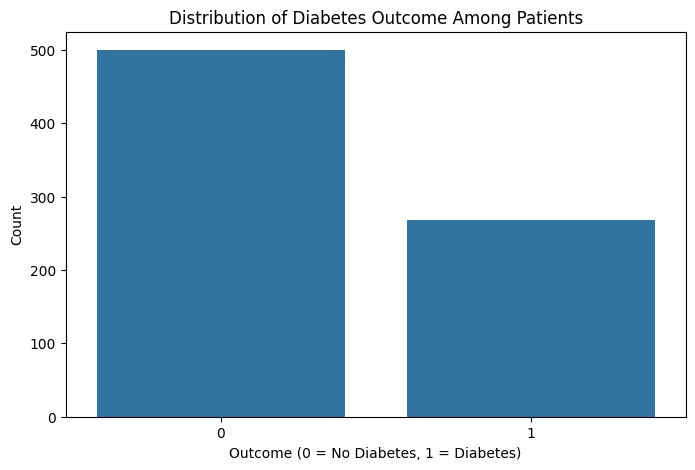

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetes Outcome Among Patients")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)


Numeric columns: ['Outcome', 'Times Pregnant', 'Blood Glucose', 'Blood Pressure', 'Skin Fold Thickness', '2-Hour Insulin', 'BMI', 'Family History', 'Age']

Categorical columns: []


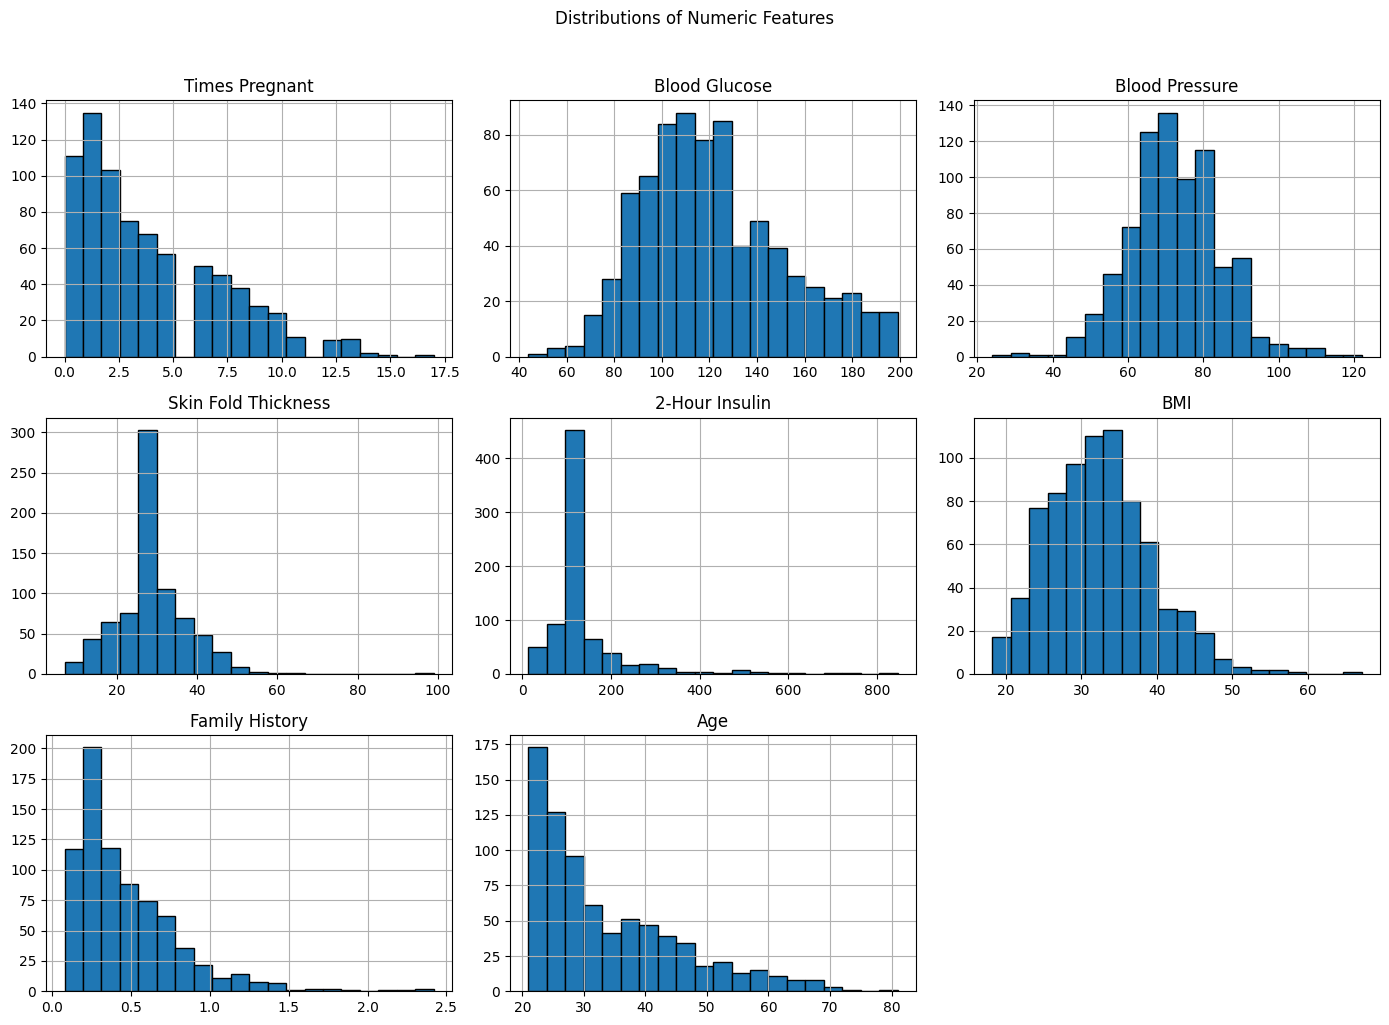

In [10]:
numeric_eda_cols = [col for col in numeric_cols if col not in ["Outcome"]]

df[numeric_eda_cols].hist(figsize=(14,10), bins=20, edgecolor="black")
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()


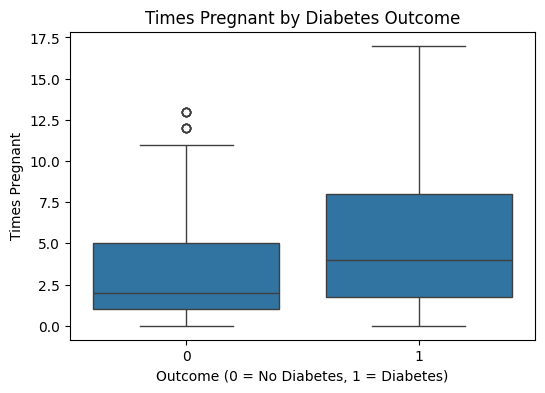

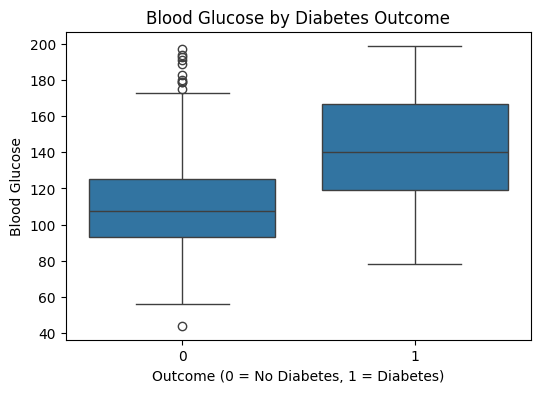

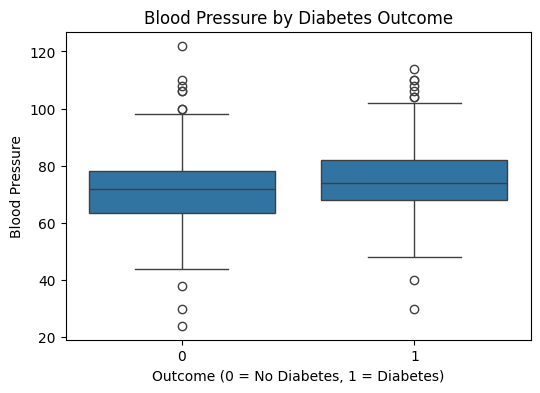

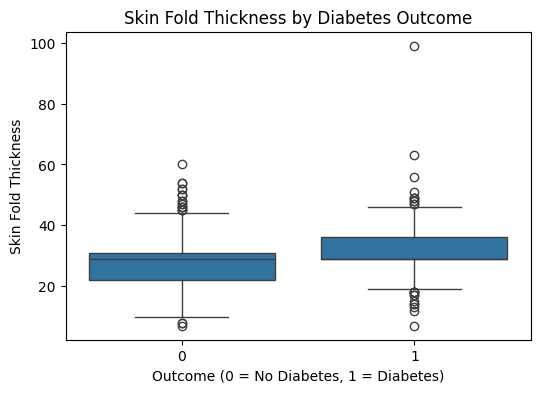

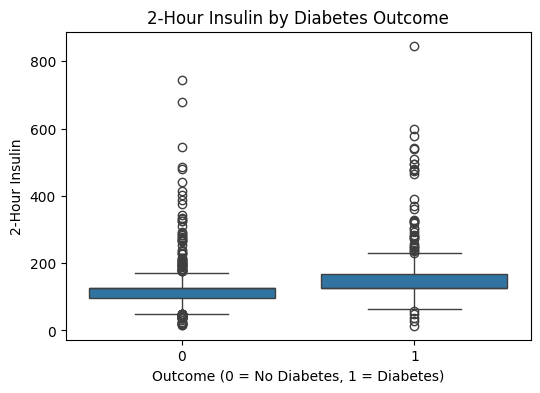

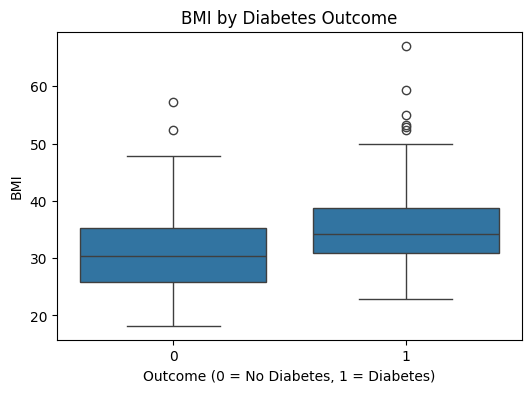

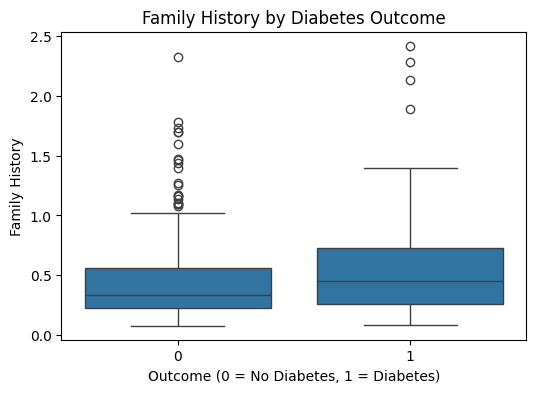

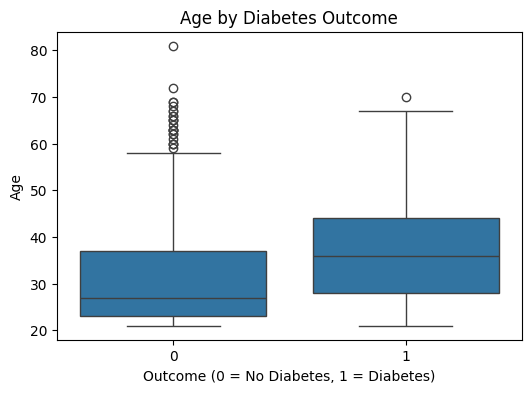

In [11]:
for col in numeric_eda_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Outcome", y=col)
    plt.title(f"{col} by Diabetes Outcome")
    plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
    plt.ylabel(col)
    plt.show()


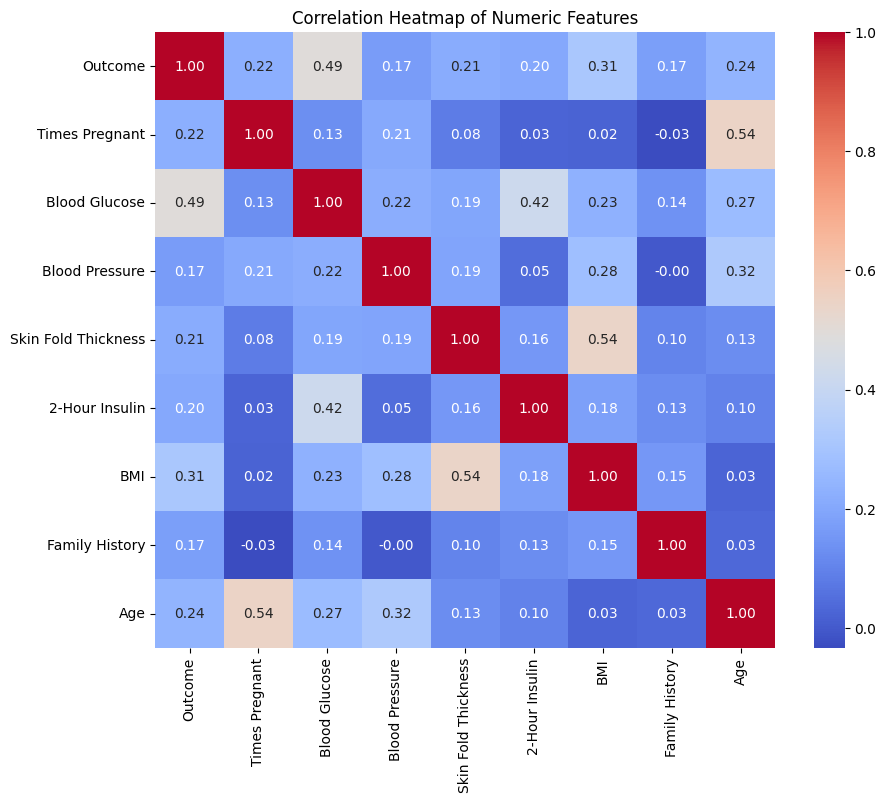

In [12]:
corr_matrix = df[[col for col in numeric_cols]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [13]:
df_encoded = df.copy()
df_encoded.info()
df_encoded.shape

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Outcome              768 non-null    int64  
 1   Times Pregnant       768 non-null    int64  
 2   Blood Glucose        768 non-null    float64
 3   Blood Pressure       768 non-null    float64
 4   Skin Fold Thickness  768 non-null    float64
 5   2-Hour Insulin       768 non-null    float64
 6   BMI                  768 non-null    float64
 7   Family History       768 non-null    float64
 8   Age                  768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


(768, 9)

In [14]:
df_encoded.describe()

,Outcome,Times Pregnant,Blood Glucose,Blood Pressure,Skin Fold Thickness,2-Hour Insulin,BMI,Family History,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.348958,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885
std,0.476951,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232
min,0.000000,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,0.000000,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000
50%,0.000000,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,1.000000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,1.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [15]:
corr_matrix2 = df_encoded.corr()
outcome_corr = corr_matrix2["Outcome"].sort_values(ascending=False)

print(outcome_corr)


Outcome                1.000000
Blood Glucose          0.492782
BMI                    0.312038
Age                    0.238356
Times Pregnant         0.221898
Skin Fold Thickness    0.214873
2-Hour Insulin         0.203790
Family History         0.173844
Blood Pressure         0.165723
Name: Outcome, dtype: float64


In [16]:
#############################################################################
#
# Train/Test Split
#
#####################

In [17]:

y = df_encoded["Outcome"]


X = df_encoded.drop(columns=["Outcome"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


In [18]:
# ================================
# Class Imbalance — SMOTE Oversampling
# ================================

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train.value_counts())
print("\nNew X_train shape:", X_train.shape)

Class distribution BEFORE SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64

New X_train shape: (800, 8)


In [19]:
# ================================
# Feature Selection 1 — Correlation Filter
# ================================


corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("Correlation with Outcome:")
display(corr)


threshold = 0.05
selected_corr_features = corr[corr > threshold].index.tolist()

print("\nSelected Features (Correlation > 0.05):")
print(selected_corr_features)


X_train_corr = X_train[selected_corr_features]
X_test_corr  = X_test[selected_corr_features]

print("\nShape after correlation filtering:")
print(X_train_corr.shape, X_test_corr.shape)

Correlation with Outcome:


Blood Glucose          0.511828
BMI                    0.356214
Skin Fold Thickness    0.247598
2-Hour Insulin         0.234627
Age                    0.231838
Blood Pressure         0.199288
Times Pregnant         0.181175
Family History         0.155337
dtype: float64


Selected Features (Correlation > 0.05):
['Blood Glucose', 'BMI', 'Skin Fold Thickness', '2-Hour Insulin', 'Age', 'Blood Pressure', 'Times Pregnant', 'Family History']

Shape after correlation filtering:
(800, 8) (154, 8)


In [20]:
# ================================
# Feature Selection 2 — RFE
# ================================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


rfe_model = LogisticRegression(max_iter=1000)


k = 6

rfe = RFE(rfe_model, n_features_to_select=k)
rfe.fit(X_train, y_train)

selected_rfe_features = X_train.columns[rfe.support_]

print("Selected Features (RFE):")
print(selected_rfe_features)


X_train_rfe = X_train[selected_rfe_features]
X_test_rfe  = X_test[selected_rfe_features]

print("\nShape after RFE:")
print(X_train_rfe.shape, X_test_rfe.shape)

Selected Features (RFE):
Index(['Times Pregnant', 'Blood Glucose', 'Blood Pressure', 'BMI',
       'Family History', 'Age'],
      dtype='str')

Shape after RFE:
(800, 6) (154, 6)


In [21]:
# ================================
# Feature Selection 3 — Random Forest Importance
# ================================

rf_fs = RandomForestClassifier(random_state=42)
rf_fs.fit(X_train, y_train)

importances = pd.Series(rf_fs.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importances:")
display(importances)


k = 6
selected_rf_features = importances.head(k).index

print("\nTop RF Features:")
print(selected_rf_features)


X_train_rf = X_train[selected_rf_features]
X_test_rf  = X_test[selected_rf_features]

print("\nShape after RF selection:")
print(X_train_rf.shape, X_test_rf.shape)

Feature Importances:


Blood Glucose          0.269675
BMI                    0.180515
Age                    0.120354
Family History         0.113535
Blood Pressure         0.090382
2-Hour Insulin         0.090349
Skin Fold Thickness    0.075090
Times Pregnant         0.060100
dtype: float64


Top RF Features:
Index(['Blood Glucose', 'BMI', 'Age', 'Family History', 'Blood Pressure',
       '2-Hour Insulin'],
      dtype='str')

Shape after RF selection:
(800, 6) (154, 6)


In [22]:
corr_set = set(selected_corr_features)
rfe_set  = set(selected_rfe_features)
rf_set   = set(selected_rf_features)
 
allofdeezmodels    = corr_set & rfe_set & rf_set
two_or_more  = (corr_set & rfe_set) | (corr_set & rf_set) | (rfe_set & rf_set)
 
print("FEATURE SELECTION RESULTS",)
 
print("Features chosen by ALL 3 methods:")
for f in sorted(allofdeezmodels):
    print(" ", f)
 
print("\nFeatures that wer chosen by at least 2 methods:")
for f in sorted(two_or_more):
    print(" ", f)

FEATURE SELECTION RESULTS
Features chosen by ALL 3 methods:
  Age
  BMI
  Blood Glucose
  Blood Pressure
  Family History

Features that wer chosen by at least 2 methods:
  2-Hour Insulin
  Age
  BMI
  Blood Glucose
  Blood Pressure
  Family History
  Times Pregnant


In [23]:
final_features = list(two_or_more)

X_train_final = X_train[final_features]
X_test_final  = X_test[final_features]

print("Shape:", X_train_final.shape, X_test_final.shape)

Shape: (800, 7) (154, 7)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
 
scorers = {'Accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'F1': 'f1'}

In [25]:
# ================================
# Model 1 — Logistic Regression
# ================================
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)
 
log_model = LogisticRegression(max_iter=1000, random_state=42)
scores_lr = cross_validate(estimator=log_model, X=X_train_scaled, y=y_train, scoring=scorers, cv=5)
 
print("Logistic Regression:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_lr['test_Accuracy'].mean(), scores_lr['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_lr['test_roc_auc'].mean(),  scores_lr['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_lr['test_F1'].mean(),       scores_lr['test_F1'].std()       * 2))
 
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
 
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression:
Acc: 0.74 (+/- 0.03)
AUC: 0.84 (+/- 0.04)
F1:  0.73 (+/- 0.03)

Test Results:
Accuracy: 0.7142857142857143
Precision: 0.5806451612903226
Recall: 0.6666666666666666
F1 Score: 0.6206896551724138
ROC-AUC: 0.8090740740740741
Confusion Matrix:
[[74 26]
 [18 36]]


In [26]:
# ================================
# Model 2 — K-Nearest Neighbors (KNN)
# ================================
 
knn_model = KNeighborsClassifier(n_neighbors=5)
scores_knn = cross_validate(estimator=knn_model, X=X_train_scaled, y=y_train, scoring=scorers, cv=5)
 
print("K-Nearest Neighbors:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_knn['test_Accuracy'].mean(), scores_knn['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_knn['test_roc_auc'].mean(),  scores_knn['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_knn['test_F1'].mean(),       scores_knn['test_F1'].std()       * 2))
 
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
 
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

K-Nearest Neighbors:
Acc: 0.80 (+/- 0.08)
AUC: 0.87 (+/- 0.10)
F1:  0.81 (+/- 0.08)

Test Results:
Accuracy: 0.7077922077922078
Precision: 0.5616438356164384
Recall: 0.7592592592592593
F1 Score: 0.6456692913385826
ROC-AUC: 0.7838888888888889
Confusion Matrix:
[[68 32]
 [13 41]]


In [27]:
# ================================
# Model 3 — Random Forest
# ================================
 
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='entropy', random_state=42)
scores_rf = cross_validate(estimator=rf_model, X=X_train_final, y=y_train, scoring=scorers, cv=5)
 
print("Random Forest:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_rf['test_Accuracy'].mean(), scores_rf['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_rf['test_roc_auc'].mean(),  scores_rf['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_rf['test_F1'].mean(),       scores_rf['test_F1'].std()       * 2))
 
rf_model.fit(X_train_final, y_train)
y_pred_rf = rf_model.predict(X_test_final)
y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]
 
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest:
Acc: 0.81 (+/- 0.09)
AUC: 0.90 (+/- 0.08)
F1:  0.82 (+/- 0.10)



Test Results:
Accuracy: 0.7467532467532467
Precision: 0.631578947368421
Recall: 0.6666666666666666
F1 Score: 0.6486486486486487
ROC-AUC: 0.8288888888888889
Confusion Matrix:
[[79 21]
 [18 36]]


In [28]:
# ================================
# Model 4 — Support Vector Machine (SVM)
# ================================
 
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
scores_svm = cross_validate(estimator=svm_model, X=X_train_scaled, y=y_train, scoring=scorers, cv=5)
 
print("Support Vector Machine:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_svm['test_Accuracy'].mean(), scores_svm['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_svm['test_roc_auc'].mean(),  scores_svm['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_svm['test_F1'].mean(),       scores_svm['test_F1'].std()       * 2))
 
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
 
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Support Vector Machine:
Acc: 0.79 (+/- 0.08)
AUC: 0.87 (+/- 0.07)
F1:  0.79 (+/- 0.07)

Test Results:
Accuracy: 0.7272727272727273
Precision: 0.59375
Recall: 0.7037037037037037
F1 Score: 0.6440677966101694
ROC-AUC: 0.8112037037037038
Confusion Matrix:
[[74 26]
 [16 38]]


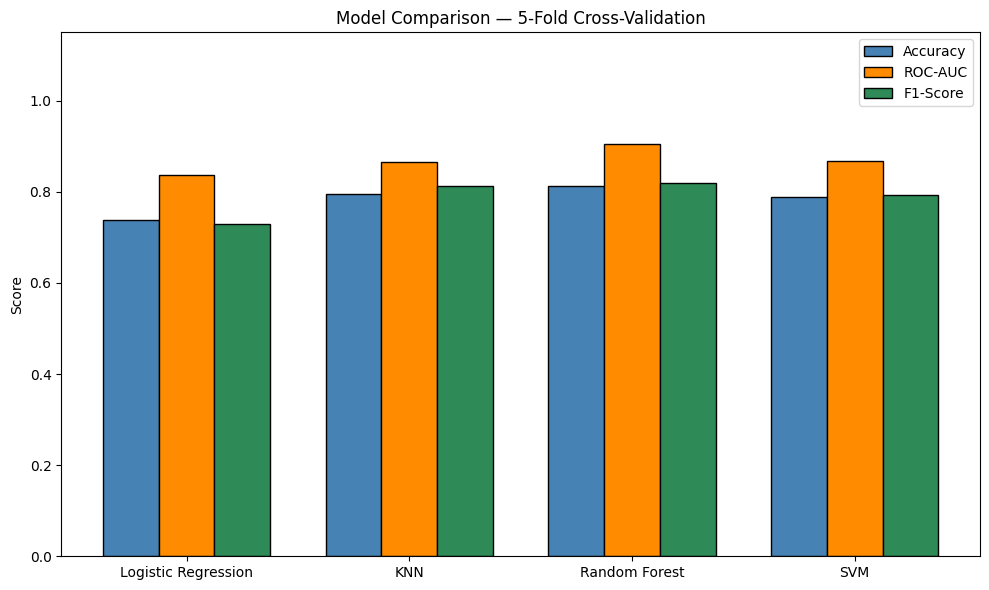

In [29]:
 
model_names = ['Logistic Regression', 'KNN', 'Random Forest', 'SVM']
cv_acc = [scores_lr['test_Accuracy'].mean(), scores_knn['test_Accuracy'].mean(), scores_rf['test_Accuracy'].mean(), scores_svm['test_Accuracy'].mean()]
cv_auc = [scores_lr['test_roc_auc'].mean(),  scores_knn['test_roc_auc'].mean(),  scores_rf['test_roc_auc'].mean(),  scores_svm['test_roc_auc'].mean()]
cv_f1  = [scores_lr['test_F1'].mean(),       scores_knn['test_F1'].mean(),       scores_rf['test_F1'].mean(),       scores_svm['test_F1'].mean()]
 
x = np.arange(len(model_names))
width = 0.25
 
plt.figure(figsize=(10, 6))
plt.bar(x - width, cv_acc, width, label='Accuracy',  color='steelblue',  edgecolor='black')
plt.bar(x,         cv_auc, width, label='ROC-AUC',   color='darkorange', edgecolor='black')
plt.bar(x + width, cv_f1,  width, label='F1-Score',  color='seagreen',   edgecolor='black')
plt.xticks(x, model_names)
plt.ylim(0, 1.15)
plt.ylabel('Score')
plt.title('Model Comparison — 5-Fold Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# ================================
# Ensemble — Voting Classifier
# ================================


from sklearn.pipeline import Pipeline


log_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=42))])
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
svm_pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=42))])
rf_pipe  = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='entropy', random_state=42)

voting_model = VotingClassifier(
    estimators=[
        ('lr',  log_pipe),
        ('knn', knn_pipe),
        ('rf',  rf_pipe),
        ('svm', svm_pipe)
    ],
    voting='soft'
)

scores_voting = cross_validate(estimator=voting_model, X=X_train_final, y=y_train, scoring=scorers, cv=5)

print("Voting Classifier (Ensemble):")
print("Acc: %0.2f (+/- %0.2f)" % (scores_voting['test_Accuracy'].mean(), scores_voting['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_voting['test_roc_auc'].mean(),  scores_voting['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_voting['test_F1'].mean(),       scores_voting['test_F1'].std()       * 2))

voting_model.fit(X_train_final, y_train)
y_pred_vote = voting_model.predict(X_test_final)
y_prob_vote = voting_model.predict_proba(X_test_final)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall:", recall_score(y_test, y_pred_vote))
print("F1 Score:", f1_score(y_test, y_pred_vote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_vote))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_vote))

Voting Classifier (Ensemble):
Acc: 0.82 (+/- 0.09)
AUC: 0.89 (+/- 0.07)
F1:  0.82 (+/- 0.09)



Test Results:
Accuracy: 0.7532467532467533
Precision: 0.625
Recall: 0.7407407407407407
F1 Score: 0.6779661016949152
ROC-AUC: 0.825925925925926
Confusion Matrix:
[[76 24]
 [14 40]]


Cluster vs Outcome cross-tabulation:
Outcome    0    1
Cluster          
0        156  195
1        344   73


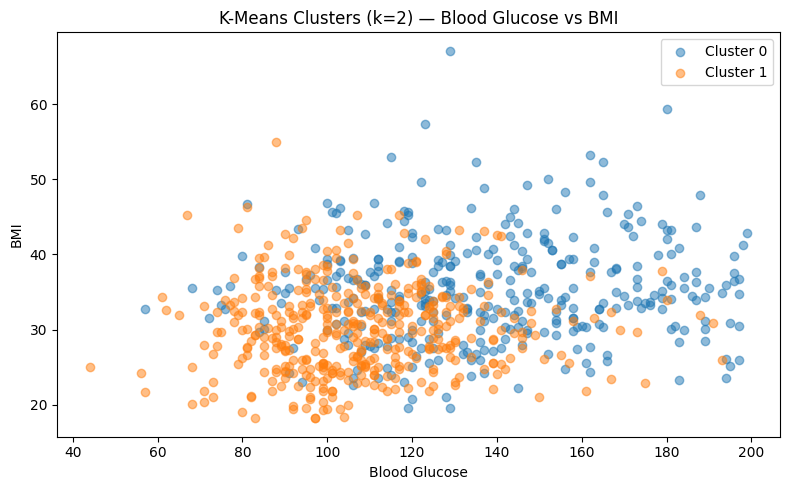

In [31]:
# ================================
# K-Means Clustering — Patient Subgroup Exploration
# ================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as SS

scaler_km = SS()
X_scaled_km = scaler_km.fit_transform(X)


kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled_km)

print("Cluster vs Outcome cross-tabulation:")
print(pd.crosstab(df['Cluster'], df['Outcome']))


plt.figure(figsize=(8,5))
for cluster in [0, 1]:
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['Blood Glucose'], subset['BMI'], label=f'Cluster {cluster}', alpha=0.5)
plt.xlabel('Blood Glucose')
plt.ylabel('BMI')
plt.title('K-Means Clusters (k=2) — Blood Glucose vs BMI')
plt.legend()
plt.tight_layout()
plt.show()